In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(23) 

In [4]:

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])

class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,
                  columns=['feature1','feature2','feature3'])

df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])

class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,
                   columns=['feature1','feature2','feature3'])

df1['target'] = 0

# replace append with concat
df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

print(df.head())

    feature1  feature2  feature3  target
35 -0.465502 -0.305861  2.231087       0
15  0.081290 -1.119842  0.437358       1
33  1.755376  0.139386  0.741368       0
38  1.811950  1.530399  1.278620       0
3  -0.093945  1.360485 -1.569843       1


In [7]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [8]:

# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [9]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[ 1.02564103  0.31894022 -0.07433075]
 [ 0.31894022  1.02564103  0.06766404]
 [-0.07433075  0.06766404  1.02564103]]


In [10]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [11]:
eigen_values

array([0.67772214, 1.34465453, 1.0545464 ])

In [12]:
eigen_vectors

array([[ 0.68076164, -0.70874924, -0.18503541],
       [-0.67798945, -0.7052892 ,  0.20711698],
       [ 0.27729748,  0.01554524,  0.96065834]])

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib
Eigen Values:

[2.57010693 0.93859518 1.25507025]

Eigen Vectors:

[[-0.72555277 -0.5258218  -0.44394212]
 [-0.37513391  0.8430402  -0.38543192]
 [-0.57692957  0.11311345  0.80892374]]


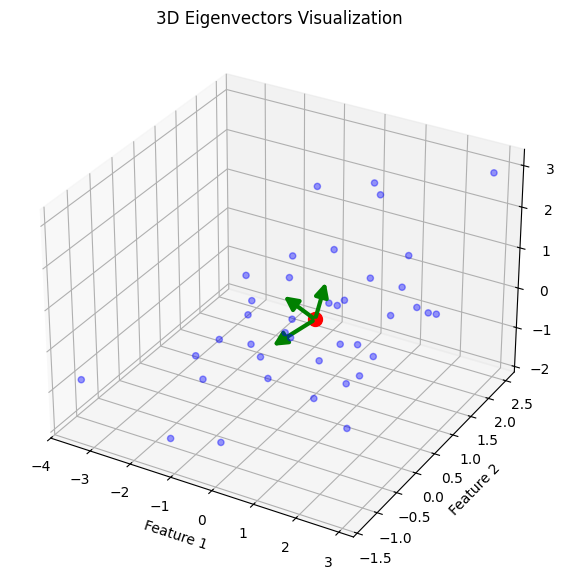

In [17]:
%pylab inline

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

# =====================================================
# Create Dataset
# =====================================================

mu_vec1 = np.array([0, 0, 0])

cov_mat1 = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

class1_sample = np.random.multivariate_normal(
    mu_vec1,
    cov_mat1,
    20
)

df = pd.DataFrame(
    class1_sample,
    columns=['feature1', 'feature2', 'feature3']
)

df['target'] = 1

mu_vec2 = np.array([1, 1, 1])

cov_mat2 = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

class2_sample = np.random.multivariate_normal(
    mu_vec2,
    cov_mat2,
    20
)

df1 = pd.DataFrame(
    class2_sample,
    columns=['feature1', 'feature2', 'feature3']
)

df1['target'] = 0

# combine datasets
df = pd.concat([df, df1], ignore_index=True)

# shuffle rows
df = df.sample(frac=1, random_state=42)

# =====================================================
# PCA
# =====================================================

X = df.drop('target', axis=1)

# covariance matrix
cov_mat = np.cov(X.T)

# eigen values and vectors
eigen_values, eigen_vectors = np.linalg.eig(cov_mat)

print("Eigen Values:\n")
print(eigen_values)

print("\nEigen Vectors:\n")
print(eigen_vectors)

# =====================================================
# Arrow Class for 3D Eigenvectors
# =====================================================

class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):

        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.get_proj()
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        super().draw(renderer)

    def do_3d_projection(self, renderer=None):

        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.get_proj()
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        return np.min(zs)

# =====================================================
# Plot
# =====================================================

fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

# plot data points
ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    color='blue',
    alpha=0.4
)

# mean point
mean_x = df['feature1'].mean()
mean_y = df['feature2'].mean()
mean_z = df['feature3'].mean()

ax.scatter(
    mean_x,
    mean_y,
    mean_z,
    color='red',
    s=100
)

# draw eigen vectors
for v in eigen_vectors.T:

    arrow = Arrow3D(
        [mean_x, mean_x + v[0]],
        [mean_y, mean_y + v[1]],
        [mean_z, mean_z + v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="green"
    )

    ax.add_artist(arrow)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")

plt.title("3D Eigenvectors Visualization")

plt.show()

In [18]:
pc = eigen_vectors[0:2]
pc

array([[-0.72555277, -0.5258218 , -0.44394212],
       [-0.37513391,  0.8430402 , -0.38543192]])

In [19]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,-0.454123,1.559605,1
1,3.597412,0.579460,1
2,0.068416,0.770468,1
3,-1.965670,-0.088034,0
4,-0.229964,0.767629,1


In [20]:

new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()